<a href="https://colab.research.google.com/github/zerpo999/spam-phishing-detection-nlp/blob/main/annel_project_spam_email_sp26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#install any missing libraries
!pip install -q ipywidgets matplotlib seaborn scikit-learn pandas numpy

In [ ]:
# ==============================
# Project 1: Spam Email Detection
# my implementation will include both SMS and email spam datasets
# ==============================

# existing imports
import pandas as pd #loading and manipulating data
import numpy as np #numerical operations and arrays
import matplotlib.pyplot as plt #creating plots and charts

from sklearn.model_selection import train_test_split #split data into training and testing sets
from sklearn.feature_extraction.text import TfidfVectorizer #convert text into numerical feature vectors

#classifiers
from sklearn.naive_bayes import MultinomialNB #Naive Bayes classifier
# new imports
from sklearn.linear_model import LogisticRegression #logistic regression
from sklearn.svm import LinearSVC #linear support vector machine
from sklearn.ensemble import RandomForestClassifier #random forest
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay #show true/false
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report

#widgets for interactive demo
from ipywidgets import interact, Text, HTML, VBox
from IPython.display import display

#confirm that all imports are successful
print("All imports have been loaded")

All imports have been loaded


In [ ]:
# Load datasets

# sms dataset
url_sms = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
sms_data = pd.read_table(url_sms, header=None, names=["label", "message"])
sms_data['label_num'] = sms_data.label.map({'ham':0, 'spam':1})
sms_data = sms_data[['message', 'label_num']].rename(columns={'label_num': 'label'})
#print how many messages are in data set
print(f"SMS dataset: {len(sms_data)} messages")

# Enron email dataset
url_enron_zip = "https://github.com/MWiechmann/enron_spam_data/raw/master/enron_spam_data.zip"
#tries to download the real data set. if it fails there is a fallback
try:
    df_email = pd.read_csv(url_enron_zip, compression='zip')
    df_email = df_email[['Message', 'Spam/Ham']].rename(columns={'Message': 'message', 'Spam/Ham': 'label'})
    df_email['label'] = df_email['label'].map({'spam': 1, 'ham': 0})
    #print success message with number of emails loaded
    print(f"Enron email dataset: {len(df_email)} emails")
except Exception as e:
    # If anything goes wrong
    # Print the error message so we know what happened
    print(f"Could not load Enron: {e}. Using fallback.")

    # Create a small list of fake email examples as a fallback
    # Each tuple is (message_text, label) where 1=spam, 0=ham
    fallback = [
        ("Get rich quick! Click here", 1),      # spam
        ("Meeting at 3pm tomorrow", 0),         # ham (legitimate)
        ("Your invoice is attached", 0),        # ham
        ("You won a lottery – claim now", 1),   # spam
        ("Urgent: verify your account", 1),     # spam (phishing)
        ("Lunch plans?", 0)                     # ham
    ]
    # Convert the list of tuples into a pandas DataFrame
    df_email = pd.DataFrame(fallback, columns=['message', 'label'])

    # Print how many fallback messages we created
    print(f"Fallback dataset created with {len(df_email)} messages")

# include phishing email dataset
phish_url = "https://zenodo.org/records/13474746/files/Phishing_validation_emails.csv?download=1"
#load the dataset
df_phish = pd.read_csv(phish_url)
print(f"Phishing email dataset loaded: {len(df_phish)} messages")

# Check original column names
print("Original columns:", df_phish.columns.tolist())

df_phish = df_phish.rename(columns={'Email Text': 'message', 'Email Type': 'label_str'})
print("Unique label values:", df_phish['label_str'].unique())
# Convert labels: 'Safe Email' -> 0, 'Phishing Email' -> 1
label_map = {
    'Safe Email': 0,
    'Phishing Email': 1
}
df_phish['label'] = df_phish['label_str'].map(label_map)
# Drop the temporary string column
df_phish = df_phish.drop(columns=['label_str'])

# Verify no missing mappings
if df_phish['label'].isna().any():
    print("Warning: Some labels were not mapped. Check unique values again.")
    print(df_phish['label_str'].value_counts())
else:
    print("Label mapping successful.")

print(f"Phishing dataset class distribution:\n{df_phish['label'].value_counts()}")

#Combine all datasets
combined_data = pd.concat([sms_data, df_email, df_phish], ignore_index=True)

# Print total number of messages in the combined dataset
print(f"\nTotal combined dataset: {len(combined_data)} messages")

print("Class distribution (0=ham/safe, 1=spam/phishing):")
print(combined_data['label'].value_counts())


SMS dataset: 5572 messages
Enron email dataset: 33716 emails
Phishing email dataset loaded: 2000 messages
Original columns: ['Email Text', 'Email Type']
Unique label values: ['Safe Email' 'Phishing Email']
Label mapping successful.
Phishing dataset class distribution:
label
0    1000
1    1000
Name: count, dtype: int64

Total combined dataset: 41288 messages
Class distribution (0=ham/safe, 1=spam/phishing):
label
0    22370
1    18918
Name: count, dtype: int64


In [ ]:
# ============================================
# TF-IDF Vectorization and Test/Train Split
# ============================================

#was giving me 'nan' errors so i added this
combined_data['message'] = combined_data['message'].astype(str)
combined_data['message'] = combined_data['message'].replace('nan', '')
combined_data = combined_data[combined_data['message'].str.strip() != '']

# Create a lower-case version of each message
# .str.lower() converts all text to lowercase so that "Free" and "free" are treated the same
combined_data['message_lower'] = combined_data['message'].str.lower()


# Create the TF-IDF vectorizer
# - stop_words='english': removes common English words like "the", "and", "a"
# - max_features=5000: only keep the 5000 most frequent words
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

# fit_transform:
#   Learns the vocabulary from the messages (fit)
#   Converts each message into a numerical vector (transform)
X = vectorizer.fit_transform(combined_data['message_lower'])

# y is the target labels (0 = ham, 1 = spam)
y = combined_data['label']

print(f"Feature matrix shape: {X.shape}")

# Split data into training and testing sets
# 30% for testing, 70% for training
# random_state=42 ensures the same random split every time (reproducibility)
# stratify=y ensures the percentage of spam/ham is the same in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Print the sizes of the resulting sets
print(f"Training set size: {X_train.shape[0]} messages")
print(f"Testing set size: {X_test.shape[0]} messages")
print(f"Number of features (unique words): {X_train.shape[1]}")

Feature matrix shape: (40917, 5000)
Training set size: 28641 messages
Testing set size: 12276 messages
Number of features (unique words): 5000


In [ ]:
# ============================================
# Train and compare 4 different models
# ============================================

#Define the models we want to test
models = {
    "Naive Bayes": MultinomialNB(),                              # Good for text classification
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),  # Simple and often works well
    "Linear SVM": LinearSVC(max_iter=2000, random_state=42, dual='auto'),       # Good for high-dimensional data
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)  # Ensemble of decision trees
}

# Create an empty list to store results for each model
results = []

#Loop through each model, train it, and evaluate
for name, model in models.items():
    model.fit(X_train, y_train) # Train the model on the training data
    y_pred = model.predict(X_test) # predict labels for the test data

    # For AUC (Area Under the ROC Curve), we need prediction probabilities or decision scores
    if hasattr(model, "predict_proba"):
        # Get probability of being spam (column 1)
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        # For SVM, decision_function gives a confidence score
        y_score = model.decision_function(X_test)

    # Calculate various performance metrics
    acc = accuracy_score(y_test, y_pred)        # Overall correctness
    prec = precision_score(y_test, y_pred)      # Of messages predicted spam, how many were actually spam?
    rec = recall_score(y_test, y_pred)          # Of actual spam messages, how many did we catch?
    f1 = f1_score(y_test, y_pred)               # Harmonic mean of precision and recall
    auc = roc_auc_score(y_test, y_score)        # How well the model separates spam from ham

    # Store these metrics in the results list as a dictionary
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "AUC": auc
    })

    # Print a classification report for this model
    print(f"\n======= {name} =======")
    # classification_report shows precision, recall, f1 for both classes (ham and spam)
    print(classification_report(y_test, y_pred, target_names=['Ham (0)', 'Spam (1)']))

#Create a DataFrame from the results and display it
results_df = pd.DataFrame(results).round(4)  # Round to 4 decimal places for readability
print("\n ==== MODEL COMPARISON TABLE ====")
print(results_df.to_string(index=False))


======= Naive Bayes =======
              precision    recall  f1-score   support

     Ham (0)       0.96      0.93      0.95      6696
    Spam (1)       0.92      0.96      0.94      5580

    accuracy                           0.94     12276
   macro avg       0.94      0.94      0.94     12276
weighted avg       0.94      0.94      0.94     12276


======= Logistic Regression =======
              precision    recall  f1-score   support

     Ham (0)       0.96      0.97      0.97      6696
    Spam (1)       0.96      0.95      0.96      5580

    accuracy                           0.96     12276
   macro avg       0.96      0.96      0.96     12276
weighted avg       0.96      0.96      0.96     12276


======= Linear SVM =======
              precision    recall  f1-score   support

     Ham (0)       0.96      0.98      0.97      6696
    Spam (1)       0.97      0.96      0.96      5580

    accuracy                           0.97     12276
   macro avg       0.97      0.97 

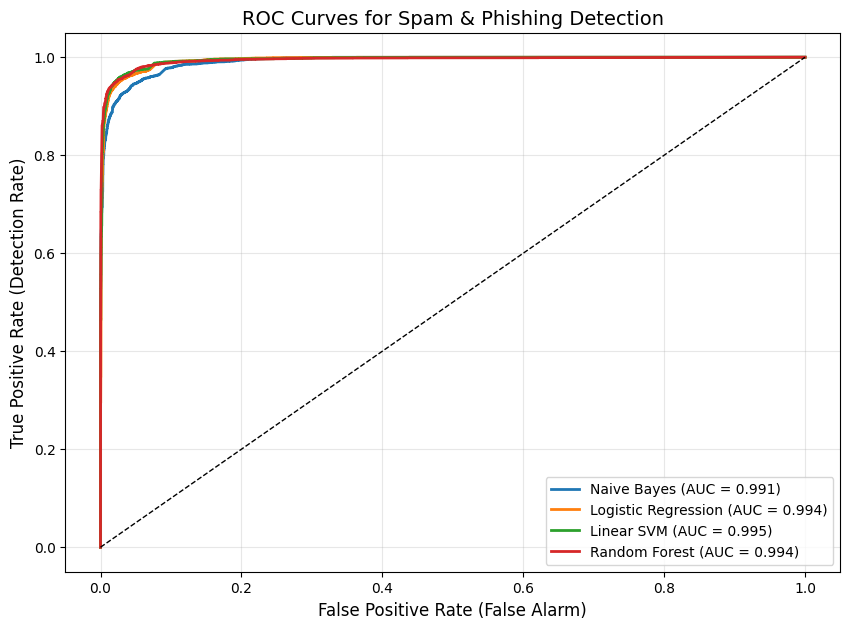

In [ ]:
# ============================================
# Plot ROC curves for all models
# ============================================

# Create a new figure with size 10 inches wide by 7 inches tall
plt.figure(figsize=(10, 7))

# Loop through each model to plot its ROC curve
for name, model in models.items():
    # Get the prediction scores (probabilities or decision function)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        continue

    # Calculate the false positive rate (fpr) and true positive rate (tpr) at different thresholds
    fpr, tpr, _ = roc_curve(y_test, y_score)

    # Calculate the Area Under the Curve (AUC) for this model
    roc_auc = roc_auc_score(y_test, y_score)

    # Plot the ROC curve for this model
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', linewidth=2)

# add the diagonal "random guess" line
# A model that guesses randomly would have AUC = 0.5, a diagonal line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)  # 'k--'  black dashed line

#add labels, title, and legend
plt.xlabel('False Positive Rate (False Alarm)', fontsize=12)   # X-axis: false alarms
plt.ylabel('True Positive Rate (Detection Rate)', fontsize=12)    # Y-axis: detection rate
plt.title('ROC Curves for Spam & Phishing Detection', fontsize=14)
plt.legend(loc="lower right")   # legend
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# ============================================
# Error analysis: which messages were misclassified
# ============================================

# Pick the best model (Logistic Regression) for error analysis
# retrain it
best_model = LogisticRegression(max_iter=1000, random_state=42)
best_model.fit(X_train, y_train)

# Predict on the test set
y_pred_best = best_model.predict(X_test)

# Find which test samples were predicted incorrectly
misclassified_idx = np.where(y_test != y_pred_best)[0]

#calculate and print misclassification statistics
total_test = len(y_test)
num_misclassified = len(misclassified_idx)
misclass_rate = num_misclassified / total_test * 100

print(f"\n Total misclassified: {num_misclassified} out of {total_test}")
print(f"Misclassification rate: {misclass_rate:.2f}%\n")

# Display the first 8 misclassified messages
print("SAMPLE MISCLASSIFIED MESSAGES (first 8):")
print("-" * 70)

# loop through the first 8 misclassified indices
for i in misclassified_idx[:8]:
    #  true label (actual class from the dataset)
    true_label = "SPAM" if y_test.iloc[i] == 1 else "HAM"
    # predicted label from our model
    pred_label = "SPAM" if y_pred_best[i] == 1 else "HAM"

    # original message text
    full_msg = combined_data.iloc[i]['message']
    # truncate long messages to 120 characters
    if len(full_msg) > 150:
        msg_preview = full_msg[:120] + "..."
    else:
        msg_preview = full_msg

    # print the details
    print(f"True: {true_label} | Pred: {pred_label}")
    print(f"Message: {msg_preview}\n")


 Total misclassified: 460 out of 12276
Misclassification rate: 3.75%

SAMPLE MISCLASSIFIED MESSAGES (first 8):
----------------------------------------------------------------------
True: SPAM | Pred: HAM
Message: URGENT! You have won a 1 week FREE membership in our £100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010 T&C www.db...

True: HAM | Pred: SPAM
Message: I HAVE A DATE ON SUNDAY WITH WILL!!

True: HAM | Pred: SPAM
Message: Fine if thats the way u feel. Thats the way its gota b

True: SPAM | Pred: HAM
Message: Pls go ahead with watts. I just wanted to be sure. Do have a great weekend. Abiola

True: SPAM | Pred: HAM
Message: 07732584351 - Rodger Burns - MSG = We tried to call you re your reply to our sms for a free nokia mobile + free camcorde...

True: SPAM | Pred: HAM
Message: i see. When we finish we have loads of loans to pay

True: HAM | Pred: SPAM
Message: K..k:)how much does it cost?

True: HAM | Pred: SPAM
Message: I know you are. Can you pls open the back?



In [ ]:
# ============================================
# interactive widget for live demo
# ============================================

# Train a final model on ALL data (train + test combined) for better performance
final_model = LogisticRegression(max_iter=1000)
final_model.fit(X, y)          # X and y are the full dataset
final_vectorizer = vectorizer  # Use the same vectorizer

#Define a function that takes a message and returns a prediction
def predict_message(msg):

    # Convert the message to numerical features using the same vectorizer
    vec = final_vectorizer.transform([msg.lower()])

    # Get the predicted class (0 or 1)
    pred = final_model.predict(vec)[0]

    # Get the prediction probabilities (confidence scores)
    prob = final_model.predict_proba(vec)[0]
    spam_prob = prob[1]   # Probability that it's spam
    ham_prob = prob[0]    # Probability that it's ham

    # Return a formatted string with emojis and confidence
    if pred == 1:
        return f"❌ **SPAM** (confidence: {spam_prob:.2%})"
    else:
        return f"✅ **HAM ** (confidence: {ham_prob:.2%})"

# interactive UI widgets
# a text box where the user can type
input_box = Text(placeholder="Type an email or SMS message here", description="Message:")

# where the prediction result will appear
output = HTML(value="<b>Prediction will appear here</b>")

#Define a function that updates the output when the user types
def update_output(change):
    # change['new'] contains the new text typed by the user
    output.value = f"<h3>{predict_message(change['new'])}</h3>"

# Observe changes to the input_box's 'value' property (when user types)
input_box.observe(update_output, names='value')

#  Display both widgets stacked vertically
print ("Enter a message to test if it's spam or ham")
display(VBox([input_box, output]))

Enter a message to test if it's spam or ham


In [ ]:
# ============================================
# show which words are most important for spam vs ham
# ============================================

#Get the vocabulary (word list) and model coefficients
# The vectorizer learned a list of all words (features) in the order they appear in the matrix
feature_names = vectorizer.get_feature_names_out()

# For Logistic Regression, the coefficient for each word tells us how much it contributes to the "spam" decision
# Positive coefficient = SPAM
# Negative coefficient = HAM
coeffs = final_model.coef_[0]

# Find the 10 words with the largest positive coefficients (spam indicators)
# np.argsort(coeffs) returns indices that would sort the coefficients from smallest to largest
# [-10:] takes the last 10 (largest), then [::-1] reverses to get descending order
top_spam_idx = np.argsort(coeffs)[-10:][::-1]
# Create list of (word, coefficient) for those indices
top_spam_words = [(feature_names[i], coeffs[i]) for i in top_spam_idx]

#Find the 10 words with the largest negative coefficients (ham indicators)
# [:10] takes the first 10 (most negative, i.e., smallest values)
top_ham_idx = np.argsort(coeffs)[:10]
top_ham_words = [(feature_names[i], coeffs[i]) for i in top_ham_idx]

#Print the results
print("Top 10 words that predict SPAM or PHISHING:")
for word, coef in top_spam_words:
    print(f"   {word}: {coef:.4f}")

print("\n Top 10 words that predict HAM or SAFE:")
for word, coef in top_ham_words:
    print(f"   {word}: {coef:.4f}")

Top 10 words that predict SPAM or PHISHING:
   http: 5.9831
   mobile: 5.2602
   info: 4.8914
   2005: 4.8619
   2004: 4.8304
   click: 4.7592
   remove: 4.3867
   software: 4.1932
   account: 4.0750
   claim: 3.8591

 Top 10 words that predict HAM or SAFE:
   enron: -12.5592
   vince: -5.7081
   2001: -5.3870
   louise: -4.7468
   questions: -4.6743
   attached: -4.6337
   713: -4.5908
   thanks: -4.4739
   2000: -4.1460
   ect: -4.1428


In [ ]:
# ============================================
# FINAL SUMMARY STATS
# ============================================

print("=" * 20)
print("FINAL PROJECT SUMMARY")
print("=" * 20)

# Dataset composition
print(f"\nDATASET COMPOSITION:")
print(f"   Total messages used: {len(combined_data)}")
print(f"   - SMS messages: {len(sms_data)}")
print(f"   - Enron emails: {len(df_email)}")
print(f"   - Phishing emails: {len(df_phish)}")

# Class distribution
spam_count = sum(y == 1)
ham_count = sum(y == 0)
print(f"\nCLASS DISTRIBUTION:")
print(f"   - Spam messages: {spam_count} ({spam_count/len(y)*100:.1f}%)")
print(f"   - Ham messages: {ham_count} ({ham_count/len(y)*100:.1f}%)")

# Best model performance
best_model_name = results_df.loc[results_df['F1 Score'].idxmax(), 'Model']
best_f1 = results_df['F1 Score'].max()
best_auc = results_df['AUC'].max()
print(f"\nBEST MODEL: {best_model_name}")
print(f"Best F1 Score: {best_f1:.4f}")
print(f"   - Best AUC: {best_auc:.4f}")

# Overall error rate
error_rate = len(misclassified_idx) / len(y_test) * 100
print(f"\n MISCLASSIFICATION RATE: {error_rate:.2f}%")
print(f"   - The model misclassifies {error_rate:.1f}% of messages")


FINAL PROJECT SUMMARY

DATASET COMPOSITION:
   Total messages used: 40917
   - SMS messages: 5572
   - Enron emails: 33716
   - Phishing emails: 2000

CLASS DISTRIBUTION:
   - Spam messages: 18599 (45.5%)
   - Ham messages: 22318 (54.5%)

BEST MODEL: Linear SVM
Best F1 Score: 0.9628
   - Best AUC: 0.9946

 MISCLASSIFICATION RATE: 3.75%
   - The model misclassifies 3.7% of messages
